# Milda Branch


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df = pd.read_csv ("data/historical_data.csv")

In [10]:
target_column_name = "is_suspicious"
feature_column_names = [col for col in df.columns if col != target_column_name]
X_full = df[feature_column_names]
y_full = df[target_column_name]

print("X shape:", X_full.shape)
print("y shape:", y_full.shape)

print("\nKlassfördelning:")
print(y_full.value_counts())

print("\nKlassfördelning i procent:")
print(y_full.value_counts(normalize=True)*100)

print("\nFörsta 5 rader i datasetet:")
display(df.head())

print("\nInformation om datasetet:")
df.info()

print("\nBeskrivande statistik för numeriska kolumner:")
display(X_full.describe())

X shape: (12000, 17)
y shape: (12000,)

Klassfördelning:
is_suspicious
0    10776
1     1224
Name: count, dtype: int64

Klassfördelning i procent:
is_suspicious
0    89.8
1    10.2
Name: proportion, dtype: float64

Första 5 rader i datasetet:


,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,is_suspicious
0,0,8,ad_post,other,urban,android,38.4,2,1,1,594.16,3,91,0,1,0,2.3,0
1,1,4,ad_post,fashion,urban,android,20.0,1,0,1,134.47,2,150,0,0,0,13.6,0
2,2,4,ad_post,other,metro,ios,46.7,3,1,1,198.52,3,72,0,0,0,4.2,0
3,3,3,ad_post,furniture,metro,android,44.3,3,1,2,141.20,3,0,0,0,0,19.8,0
4,4,1,ad_post,electronics,metro,web,211.2,5,0,0,81.39,3,9,0,0,1,23.3,0



Information om datasetet:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          12000 non-null  int64  
 1   day                         12000 non-null  int64  
 2   event_type                  12000 non-null  object 
 3   category                    12000 non-null  object 
 4   region                      11660 non-null  object 
 5   device                      12000 non-null  object 
 6   account_age_days            12000 non-null  float64
 7   num_prev_listings           12000 non-null  int64  
 8   prev_reports_30d            12000 non-null  int64  
 9   verification_level          12000 non-null  int64  
 10  price                       11182 non-null  float64
 11  num_images                  12000 non-null  int64  
 12  message_length              12000 non-null  int64  
 13  cont

,id,day,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min
count,12000.00000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11182.000000,12000.000000,12000.000000,12000.000000,12000.000000,12000.000000,11410.000000
mean,5999.50000,7.482667,99.632567,3.027750,0.151500,0.710167,207.348603,2.870417,111.154417,0.072833,0.099083,0.181167,22.160438
std,3464.24595,4.032520,112.903541,1.766467,0.386083,0.719171,196.226023,1.766886,66.396885,0.259874,0.298786,0.385172,28.834047
min,0.00000,1.000000,2.200000,0.000000,0.000000,0.000000,7.670000,0.000000,0.000000,0.000000,0.000000,0.000000,0.300000
25%,2999.75000,4.000000,36.300000,2.000000,0.000000,0.000000,86.195000,2.000000,63.000000,0.000000,0.000000,0.000000,6.700000
50%,5999.50000,7.000000,66.600000,3.000000,0.000000,1.000000,149.225000,3.000000,108.000000,0.000000,0.000000,0.000000,13.400000
75%,8999.25000,11.000000,120.700000,4.000000,0.000000,1.000000,256.795000,4.000000,155.000000,0.000000,0.000000,0.000000,26.600000
max,11999.00000,14.000000,2741.700000,12.000000,3.000000,2.000000,2743.080000,10.000000,416.000000,1.000000,1.000000,1.000000,579.800000


### Datasetöversikt

Datasetet innehåller 12 000 rader och 18 kolumner.

Kolumnerna innehåller både numeriska och kategoriska variabler.

Target-kolumnen is_suspicious visar om en händelse är misstänkt (1) eller inte misstänkt (0).

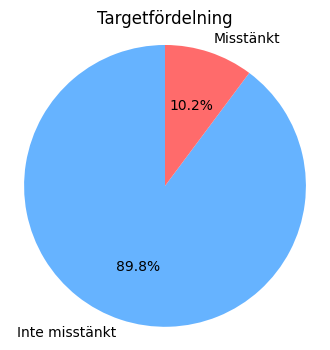

In [11]:
value = df["is_suspicious"].value_counts()

plt.figure(figsize=(4,4))
plt.pie(value,
        labels=["Inte misstänkt", "Misstänkt"],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#66b3ff',  '#FF6B6B'])

plt.title("Targetfördelning")
plt.axis('equal')

plt.show()

### Targetfördelning

Diagrammet visar att majoriteten av händelserna är icke-misstänkta - cirka 89.8%, medan ungefär 10.2% är misstänkta.

In [12]:
print("Saknade värden:")
missing_number = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_number / len(df))*100
missing_table = pd.DataFrame ( {
    "Antal saknade värden": missing_number,
    "Andel (%)": missing_percent.round(2)
})
missing_table = missing_table[missing_table["Antal saknade värden"] > 0]
missing_table

Saknade värden:


,Antal saknade värden,Andel (%)
price,818,6.82
time_to_first_response_min,590,4.92
region,340,2.83


### Saknade värden

Datasetet innehåller saknade värden i några kolumner.


Kolumnen price har 818 (6.82%) saknade värden.

Kolumnen time_to_first_response_min har 590 (4.92%) saknade värden.

Kolumnen region har 340 (2.83%) saknade värden.


Saknade värden kommer att hanteras i preprocessing-steget.
Numeriska värden kan ersättas med medianvärdet, medan kategoriska värden kan ersättas med det mest förekommande värdet (most frequent).
Detta görs för att modellen ska kunna tränas korrekt utan saknade värden i data.

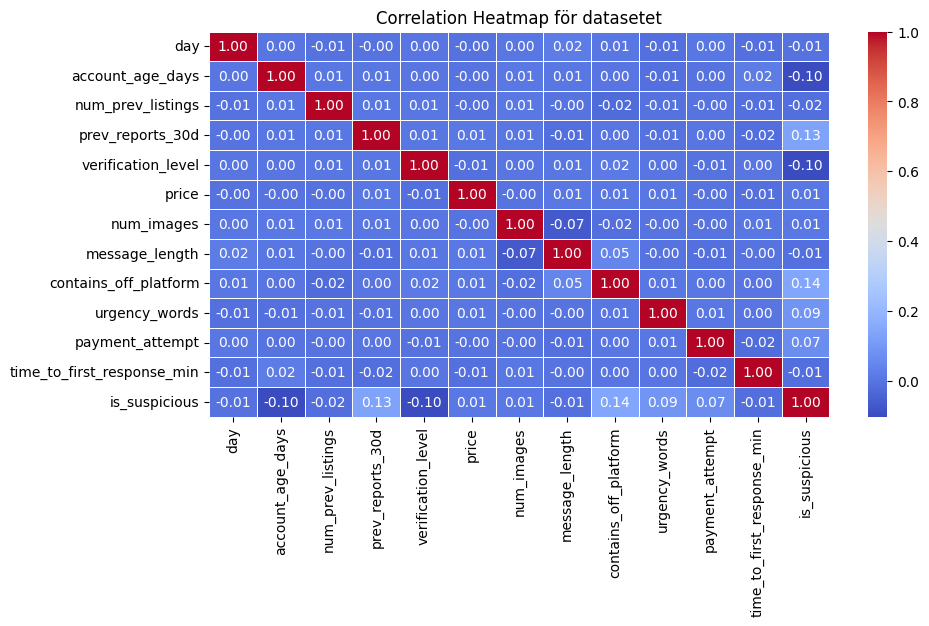

Numeriska kolumner och deras relation till target


,Relation till target
contains_off_platform,0.142
prev_reports_30d,0.131
urgency_words,0.087
payment_attempt,0.067
price,0.012
num_images,0.009
id,0.005
day,-0.008
message_length,-0.012
time_to_first_response_min,-0.014


In [13]:
corr = df.drop(columns=["id"]).select_dtypes(include="number").corr()

plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap för datasetet")
plt.show()

print("Numeriska kolumner och deras relation till target")
corr_target = df.select_dtypes(include="number").corr()[["is_suspicious"]]
corr_target = corr_target.drop("is_suspicious")
corr_target = corr_target.sort_values(by="is_suspicious", ascending=False)

corr_target = corr_target.round(3)
corr_target.columns = ["Relation till target"]

display(corr_target)

### Relation mellan numeriska kolumner och target

Correlation Heatmap och tabellen "Numeriska kolumner och deras relation till target" visar hur numeriska kolumner i datasetet relaterar till target-kolumnen is_suspicious.

Kolumnerna contains_off_platform och prev_reports_30d visar den starkaste relationen till target.

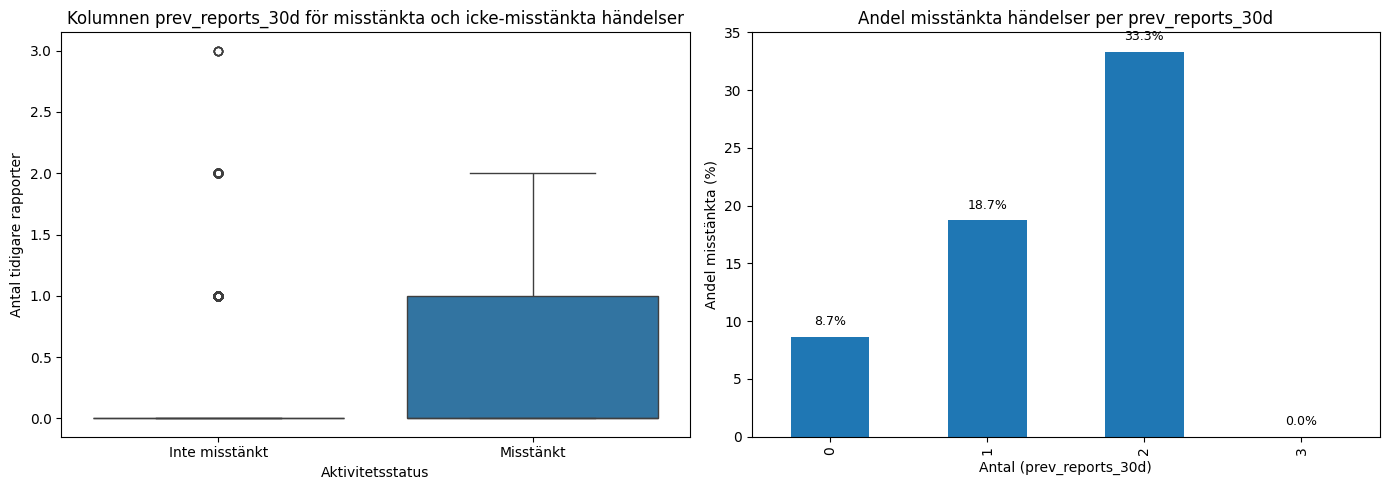

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.boxplot(x="is_suspicious", y="prev_reports_30d", data=df, ax=axes[0])
axes[0].set_title("Kolumnen prev_reports_30d för misstänkta och icke-misstänkta händelser")
axes[0].set_xlabel("Aktivitetsstatus")
axes[0].set_ylabel("Antal tidigare rapporter")
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(["Inte misstänkt", "Misstänkt"])


risk = df.groupby("prev_reports_30d")["is_suspicious"].mean()*100
risk.plot(kind="bar", ax=axes[1])

axes[1].set_title("Andel misstänkta händelser per prev_reports_30d")
axes[1].set_xlabel("Antal (prev_reports_30d)")
axes[1].set_ylabel("Andel misstänkta (%)")

for i, v in enumerate(risk):
    axes[1].text(i, v + 1, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### Kolumnen prev_reports_30d för misstänkta och icke-misstänkta händelser

Diagrammet till vänster visar hur värden i kolumnen prev_reports_30d fördelar sig mellan misstänkta och icke-misstänkta händelser.

De flesta icke-misstänkta händelser har värdet 0 i kolumnen prev_reports_30d, medan misstänkta händelser oftare har värden över 0 (1-2).

Diagrammet till höger visar andelen misstänkta händelser beroende på antalet tidigare rapporter (prev_reports_30d).

Andelen misstänkta händelser ökar när värdet på prev_reports_30d ökar.


# Modelljämförelse - Azar's branch

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, roc_auc_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

In [16]:
path = "data/historical_data.csv"
df = pd.read_csv(path)

print(f"{df.shape[0]} rader, {df.shape[1]} kolumner")
print(f"\nTarget-fördelning:")
print(df["is_suspicious"].value_counts())

12000 rader, 18 kolumner

Target-fördelning:
is_suspicious
0    10776
1     1224
Name: count, dtype: int64


### Separera features och target och Train/Test Split 80/20 

In [17]:
target_column = "is_suspicious"
X = df.drop(columns=[target_column, "id"]) 
y = df[target_column]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,  
    random_state=42
)

print(f"Train set: {X_train.shape[0]} (klass fördelning: {y_train.value_counts().to_dict()})")
print(f"Test set: {X_test.shape[0]} (klass fördelning: {y_test.value_counts().to_dict()})")

X shape: (12000, 16)
y shape: (12000,)
Train set: 9600 (klass fördelning: {0: 8621, 1: 979})
Test set: 2400 (klass fördelning: {0: 2155, 1: 245})


### Preproccesing pipeline 

In [18]:
categorical_features = [
    "event_type",
    "category",
    "region",
    "device"
]

numeric_features = [
    "day",
    "account_age_days",
    "num_prev_listings",
    "prev_reports_30d",
    "price",
    "num_images",
    "verification_level",
    "contains_off_platform",
    "urgency_words",
    "payment_attempt",
    "message_length",
    "time_to_first_response_min"
]

print(f"Kategoriska features: {len(categorical_features)}")
print(f"Numeriska features: {len(numeric_features)}")

# Numeriska transformer
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Kategoriska transformer
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Båda
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline skapad")

Kategoriska features: 4
Numeriska features: 12
Preprocessing pipeline skapad


## 3 modeller
### Baseline + 2 andra

In [19]:
models = {
    "Baseline (Dummy Classifier)": DummyClassifier(strategy="most_frequent", random_state=42),
    
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight="balanced" 
    ),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        max_depth=10,
        class_weight="balanced", 
        n_jobs=-1  
    )
}

print(f"{len(models)} modeller definierade:")
for name in models.keys():
    print(f"  - {name}")

3 modeller definierade:
  - Baseline (Dummy Classifier)
  - Logistic Regression
  - Random Forest


### CV Setup

In [20]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(f"Stratified K-Fold CV (5 splits)")

Stratified K-Fold CV (5 splits)


### Träna alla modeller

In [21]:
metrics_to_calculate = {
    "recall": "recall",      
    "roc_auc": "roc_auc",    
    "precision": "precision" 
}

print(f"Metriker som beräknas:")
print(f"  - Recall (PRIMÄR): Fångar vi misstänkta fall?")
print(f"  - ROC-AUC (SEKUNDÄR): Generell klassificeringsförmåga")
print(f"  - Precision: Av dem vi flaggade, hur många var faktiskt misstänkta?")

Metriker som beräknas:
  - Recall (PRIMÄR): Fångar vi misstänkta fall?
  - ROC-AUC (SEKUNDÄR): Generell klassificeringsförmåga
  - Precision: Av dem vi flaggade, hur många var faktiskt misstänkta?


In [22]:
results = {}

print("\n")
print("EVALUERING PÅ GÅNG")
for model_name, model in models.items():
    print(f"\n Testar: {model_name}")
    
    
    full_pipeline = Pipeline([
        ("preprocessing", preprocessor),
        ("model", model)
    ])
    
    
    model_results = {}
    
    for metric_display_name, metric_sklearn in metrics_to_calculate.items():
        cv_scores = cross_val_score(
            full_pipeline,
            X_train,
            y_train,
            cv=cv,
            scoring=metric_sklearn,
            n_jobs=1
        )
        
        model_results[metric_display_name] = {
            "mean": cv_scores.mean(),
            "std": cv_scores.std(),
            "scores": cv_scores
        }
        
        print(f"  {metric_display_name.upper():12} = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    
    results[model_name] = model_results

print("\n")



EVALUERING PÅ GÅNG

 Testar: Baseline (Dummy Classifier)
  RECALL       = 0.0000 (+/- 0.0000)
  ROC_AUC      = 0.5000 (+/- 0.0000)
  PRECISION    = 0.0000 (+/- 0.0000)

 Testar: Logistic Regression
  RECALL       = 0.6517 (+/- 0.0258)
  ROC_AUC      = 0.7359 (+/- 0.0207)
  PRECISION    = 0.1929 (+/- 0.0064)

 Testar: Random Forest
  RECALL       = 0.2380 (+/- 0.0235)
  ROC_AUC      = 0.7130 (+/- 0.0084)
  PRECISION    = 0.2442 (+/- 0.0175)




### Sammanfattning

In [23]:
results_summary = pd.DataFrame({
    model_name: {
        "Recall (mean)": results[model_name]["recall"]["mean"],
        "Recall (std)": results[model_name]["recall"]["std"],
        "ROC-AUC (mean)": results[model_name]["roc_auc"]["mean"],
        "ROC-AUC (std)": results[model_name]["roc_auc"]["std"],
        "Precision (mean)": results[model_name]["precision"]["mean"],
        "Precision (std)": results[model_name]["precision"]["std"],
    }
    for model_name in models.keys()
}).T

results_summary = results_summary.round(4)

print("\n JÄMFÖRELSE AV ALLA MODELLER:\n")
print(results_summary)

results_summary.to_csv("model_comparison_results.csv")
print("\nResultat sparade till: model_comparison_results.csv")


 JÄMFÖRELSE AV ALLA MODELLER:

                             Recall (mean)  Recall (std)  ROC-AUC (mean)  \
Baseline (Dummy Classifier)         0.0000        0.0000          0.5000   
Logistic Regression                 0.6517        0.0258          0.7359   
Random Forest                       0.2380        0.0235          0.7130   

                             ROC-AUC (std)  Precision (mean)  Precision (std)  
Baseline (Dummy Classifier)         0.0000            0.0000           0.0000  
Logistic Regression                 0.0207            0.1929           0.0064  
Random Forest                       0.0084            0.2442           0.0175  

Resultat sparade till: model_comparison_results.csv


### Modelljämförelse 

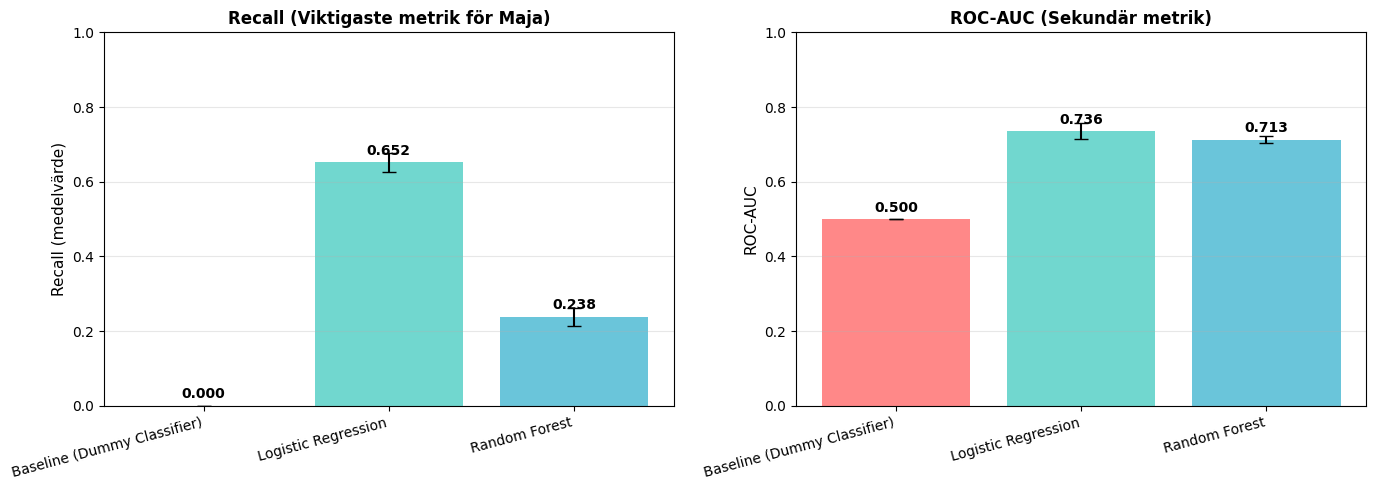

Figur sparad oi model_comparison_visualization.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

recall_values = [results[name]["recall"]["mean"] for name in models.keys()]
recall_stds = [results[name]["recall"]["std"] for name in models.keys()]
model_names = list(models.keys())

axes[0].bar(range(len(model_names)), recall_values, yerr=recall_stds, capsize=5, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
axes[0].set_xticks(range(len(model_names)))
axes[0].set_xticklabels(model_names, rotation=15, ha="right")
axes[0].set_ylabel("Recall (medelvärde)", fontsize=11)
axes[0].set_title("Recall (Viktigaste metrik för Maja)", fontsize=12, fontweight="bold")
axes[0].set_ylim([0, 1])
axes[0].grid(axis="y", alpha=0.3)

for i, v in enumerate(recall_values):
    axes[0].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

roc_auc_values = [results[name]["roc_auc"]["mean"] for name in models.keys()]
roc_auc_stds = [results[name]["roc_auc"]["std"] for name in models.keys()]

axes[1].bar(range(len(model_names)), roc_auc_values, yerr=roc_auc_stds, capsize=5, color=['#FF6B6B', '#4ECDC4', '#45B7D1'], alpha=0.8)
axes[1].set_xticks(range(len(model_names)))
axes[1].set_xticklabels(model_names, rotation=15, ha="right")
axes[1].set_ylabel("ROC-AUC", fontsize=11)
axes[1].set_title("ROC-AUC (Sekundär metrik)", fontsize=12, fontweight="bold")
axes[1].set_ylim([0, 1])
axes[1].grid(axis="y", alpha=0.3)

for i, v in enumerate(roc_auc_values):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("model_comparison_visualization.png", dpi=300, bbox_inches="tight")
plt.show()

print("Figur sparad oi model_comparison_visualization.png")

## Vinnare och Analys

Logistic Regression är bäst för Majas behov.

**Recall: 0.6517** betyder vi fångar ca 65% av misstänkta fall.

Varför inte Random Forest? 
- Recall var bara 0.2390 - för lågt för Maja
- Logistic Regression är mycket enklare att förklara
- Vi kan säga: "Högre risk-poäng = mer misstänkt" 

Det passar Majas behov perfekt.


### Trade-offs: 
   Recall vs Precision:
   - Vi väljer högt Recall (fånga misstänkta)
   - Det betyder färre False Negatives (misstänkta som glider igenom)
   - Men mer False Positives (icke-misstänkta som flaggas)

# Optimering - Bens Branch

In [25]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

model_to_tune = models["Logistic Regression"]

tuning_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", model_to_tune)
])

param_grid = {
#    'model__C': [0.1, 1.0, 10.0, 100.0]
#    'model__C': [0.7, 0.8, 0.9, 0.11]
#    'model__C': [0.4, 0.5, 0.6, 0.7]
    'model__C': [0.1, 0.2, 0.3, 0.4]
}

grid_search = GridSearchCV(
    tuning_pipeline,
    param_grid,
    cv=5,
    scoring='recall',
    verbose=1
)

grid_search.fit(X_train, y_train)

best_log_reg_model = grid_search.best_estimator_
grid_search.best_params_



Fitting 5 folds for each of 4 candidates, totalling 20 fits


{'model__C': 0.3}

## Vad har optimerats och varför?
**Vad?**
 - Recall har prioriterats för modellen
 - Parametern C har finjusterats och landat på 0,3

**Varför?**
 - Recall har prioriterats eftersom att kostnaden för att missa en bedragare är högre än för att granska en oskyldig annons extra. Det möter Majas krav om att helltre titta på ett extra fall.
 - Ett lägre C värde motverkar att modellen blir för komplicerad eller snäv. Det gör lösningen mer stabil och möter Majas krav om en pålitlig trygghetsfunktion.


# Threshold/prioritering - Idas Branch

In [26]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score

final_model = best_log_reg_model

proba = final_model.predict_proba(X_test)[:, 1]

result = X_test.copy()
result["y_true"] = y_test.values
result["p_risk"] = proba

result = result.sort_values("p_risk", ascending=False).reset_index(drop=True)

results = []

for top_percentage in [0.05, 0.10]:

    k = int(len(result) * top_percentage)

    top_data = result.copy()
    top_data["y_pred"] = 0
    top_data.loc[:k-1, "y_pred"] = 1


    tn, fp, fn, tp = confusion_matrix(top_data["y_true"], top_data["y_pred"]).ravel()
    recall = recall_score(top_data["y_true"], top_data["y_pred"])
    
    results.append({"Top-%": top_percentage * 100, "Antal flaggade": k, "False Positives": fp, "False Negatives": fn, "Recall": recall})

df_results = pd.DataFrame(results)
df_results


,Top-%,Antal flaggade,False Positives,False Negatives,Recall
0,5.0,120,76,201,0.179592
1,10.0,240,166,171,0.302041


### Motivering av Top-X
Top-X är den valda prioriteringsstrategin eftersom kravkortet fokuserar på hög recall och att minimera False Negatives.

### Resultat och tolkning
Resultaten visar att när vi ökar X minskar FN och recall ökar, vilket innebär att färre riskfall missas. Däremot ökar False Positives (FP), vilket är en förväntad trade-off och acceptabelt utifrån stakeholderns prioriteringar.

# Predikt av New_data


In [37]:
new_data = pd.read_csv("data/new_data.csv")

X_new = new_data.drop(columns=["id"], errors="ignore")

proba_new = final_model.predict_proba(X_new)[:, 1]
new_data["p_risk"] = proba_new


new_data = new_data.sort_values("p_risk", ascending=False).reset_index(drop=True)


top_percentage = 0.10
k = int(len(new_data) * top_percentage)

new_data["is_flagged"] = 0
new_data.loc[:k-1, "is_flagged"] = 1
print(f"Totalt antal fall: {len(new_data)}")
print(f"Antal flaggade (Top {top_percentage*100}%): {k}")
new_data.to_csv("data/resualt_data.csv")
new_data.head(10)


Totalt antal fall: 2000
Antal flaggade (Top 10.0%): 200


,id,day,event_type,category,region,device,account_age_days,num_prev_listings,prev_reports_30d,verification_level,price,num_images,message_length,contains_off_platform,urgency_words,payment_attempt,time_to_first_response_min,p_risk,is_flagged
0,1092,2,ad_post,furniture,metro,android,27.9,5,2,0,NaN,3,64,1,0,0,8.8,0.971129,1
1,1398,5,message_send,other,rural,android,31.4,3,1,0,235.12,1,189,1,1,0,13.9,0.965349,1
2,1547,3,ad_post,other,metro,android,46.1,1,1,0,128.28,7,141,1,0,1,71.2,0.948967,1
3,1130,1,ad_post,phones,urban,android,23.5,3,2,1,169.80,3,229,1,0,0,5.2,0.941980,1
4,1064,4,message_send,bikes,rural,android,33.3,0,1,0,202.65,1,161,0,1,1,NaN,0.934526,1
5,486,5,ad_post,fashion,rural,android,11.7,2,1,0,292.44,4,213,1,0,0,NaN,0.934072,1
6,124,4,message_send,other,rural,android,16.0,4,1,0,99.13,6,156,1,0,0,25.4,0.932709,1
7,1831,3,ad_post,furniture,NaN,ios,15.4,3,1,0,90.61,5,125,1,0,0,NaN,0.932545,1
8,181,5,message_send,bikes,metro,ios,37.2,0,1,0,113.18,2,150,0,1,1,34.9,0.932158,1
9,1538,2,ad_post,phones,urban,android,47.8,3,2,1,227.32,0,158,1,0,0,22.2,0.931899,1


# Sammanfattning av resultat 

Modellen användes för att prediktera risk på 2000 nya observationer.
Varje observation tilldelades ett riskscore (p_risk) mellan 0 och 1.

Baserat på vald strategi (Top 10%) flaggades:

200 av 2000 fall (10%) som misstänkta

Riskscoren varierade mellan:

0.0004 (låg risk) och 0.9711 (hög risk)

Medelvärde: 0.45

De högst rankade fallen (top 10%) har mycket höga sannolikheter (>0.9), vilket tyder på att modellen tydligt kan identifiera potentiellt misstänkta fall.